# Fraud Detection - Selected Production Stack Inference Notebook

This notebook loads the selected fraud detection production stack and performs inference without training any model.

The selected stack comes from the meta-feature combination study:

- Random Forest
- CatBoost
- XGBoost
- Logistic Regression Meta-Model

The business goal is to catch as many fraud cases as possible while keeping false alerts reasonable. Therefore, the final threshold is loaded from the selected production stack artifact.


# Initial Setup


## Install and Import Libraries


In [ ]:
%%capture
!pip install -q ipython-autotime
!pip install -q gdown
!pip install -q kagglehub joblib pandas numpy scikit-learn xgboost catboost
%load_ext autotime

time: 5.64 s (started: 2026-06-18 08:17:49 +00:00)


In [ ]:
import os
import joblib
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown
import kagglehub

from IPython.display import display

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier


time: 372 µs (started: 2026-06-18 08:17:55 +00:00)


## Global Parameters


In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LABELS = ["Legitimate", "Fraud"]

SELECTED_STACK_NAME = "RF + CAT + XGB"

SELECTED_META_FEATURES = [
    "rf_prob",
    "cat_prob",
    "xgb_prob",
]

DEFAULT_THRESHOLD = 0.5

print("Selected stack:", SELECTED_STACK_NAME)
print("Selected meta feature order:")
print(SELECTED_META_FEATURES)
print("Default threshold:", DEFAULT_THRESHOLD)


Selected stack: RF + CAT + XGB
Selected meta feature order:
['rf_prob', 'cat_prob', 'xgb_prob']
Default threshold: 0.5
time: 344 µs (started: 2026-06-18 08:17:55 +00:00)


## Download Saved Artifacts with gdown

The notebook downloads only the artifacts required for the selected production stack:

- preprocessing artifacts
- Random Forest model
- CatBoost model
- XGBoost model
- Selected production stack artifact

No training is performed in this notebook.

In [ ]:
ARTIFACT_DIR = "/content/fraud_selected_stack_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

artifact_file_ids = {
    "preprocessing_artifacts.joblib": "12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ",
    "random_forest.joblib": "12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC",
    "catboost.cbm": "1c8QLXfW0rp3H3M9dyS4obI43oxPMjrAn",
    "xgboost.json": "1AerxFemFwZQita5ni0IQK4eJ19vBN7n_",
    "production_stack_artifacts.joblib": "1gvPe7Gu3MBmp4-XGII7I4N79_vUGge6N",
}

artifact_paths = {}

for filename, file_id in artifact_file_ids.items():
    output_path = os.path.join(ARTIFACT_DIR, filename)
    artifact_paths[filename] = output_path

    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_path, quiet=False)

print("\nArtifact paths:")
for name, path in artifact_paths.items():
    print(name, "->", path)


Downloading...
From: https://drive.google.com/uc?id=12wDMl5MU6kNcLoFXTKw3Ex51853OzdCZ
To: /content/fraud_selected_stack_artifacts/preprocessing_artifacts.joblib
100%|██████████| 33.3k/33.3k [00:00<00:00, 18.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC
From (redirected): https://drive.google.com/uc?id=12nMtybkXtj6TGg_t_9Kt-j7VmVspnVbC&confirm=t&uuid=4b2d33a4-7174-4a28-bcb0-806bad9c801e
To: /content/fraud_selected_stack_artifacts/random_forest.joblib
100%|██████████| 125M/125M [00:01<00:00, 65.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1c8QLXfW0rp3H3M9dyS4obI43oxPMjrAn
To: /content/fraud_selected_stack_artifacts/catboost.cbm
100%|██████████| 1.49M/1.49M [00:00<00:00, 11.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AerxFemFwZQita5ni0IQK4eJ19vBN7n_
To: /content/fraud_selected_stack_artifacts/xgboost.json
100%|██████████| 2.24M/2.24M [00:00<00:00, 14.5MB/s]
Downloading...
From: https://drive.google.com


Artifact paths:
preprocessing_artifacts.joblib -> /content/fraud_selected_stack_artifacts/preprocessing_artifacts.joblib
random_forest.joblib -> /content/fraud_selected_stack_artifacts/random_forest.joblib
catboost.cbm -> /content/fraud_selected_stack_artifacts/catboost.cbm
xgboost.json -> /content/fraud_selected_stack_artifacts/xgboost.json
production_stack_artifacts.joblib -> /content/fraud_selected_stack_artifacts/production_stack_artifacts.joblib
time: 11.3 s (started: 2026-06-18 08:17:55 +00:00)


## Load Saved Artifacts


In [ ]:
preprocessing_artifacts = joblib.load(
    artifact_paths["preprocessing_artifacts.joblib"]
)

rf_model = joblib.load(
    artifact_paths["random_forest.joblib"]
)

cat_model = CatBoostClassifier()
cat_model.load_model(
    artifact_paths["catboost.cbm"]
)

xgb_model = XGBClassifier()
xgb_model.load_model(
    artifact_paths["xgboost.json"]
)

production_stack_artifacts = joblib.load(
    artifact_paths["production_stack_artifacts.joblib"]
)

meta_model = production_stack_artifacts["meta_model"]
production_threshold = float(production_stack_artifacts["threshold"])
production_feature_set = production_stack_artifacts["feature_set"]
production_stack_name = production_stack_artifacts["stack_name"]

print("All selected production artifacts loaded successfully.")


All selected production artifacts loaded successfully.
time: 126 ms (started: 2026-06-18 08:18:06 +00:00)


## Inspect Production Stack Artifacts

The production stack artifact is the map of the selected model. It tells us which base-model probabilities to use, which meta-model to apply, and which threshold was selected by the business optimization study.


In [ ]:
print("Production stack name:")
print(production_stack_name)

print("\nProduction feature set:")
print(production_feature_set)

print("\nProduction threshold:")
print(production_threshold)

print("\nMeta model type:")
print(type(meta_model))

assert production_stack_name == SELECTED_STACK_NAME, "Selected stack name mismatch!"
assert production_feature_set == tuple(SELECTED_META_FEATURES), "Selected meta-feature order mismatch!"

print("\nProduction stack artifact check passed.")

Production stack name:
RF + CAT + XGB

Production feature set:
('rf_prob', 'cat_prob', 'xgb_prob')

Production threshold:
0.69

Meta model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

Production stack artifact check passed.
time: 465 µs (started: 2026-06-18 08:18:06 +00:00)


## Artifact Validation


In [ ]:
required_artifacts = [
    "preprocessing_artifacts.joblib",
    "random_forest.joblib",
    "catboost.cbm",
    "xgboost.json",
    "production_stack_artifacts.joblib",
]

print("=" * 80)
print("VALIDATING SELECTED STACK ARTIFACTS")
print("=" * 80)

for artifact_name in required_artifacts:
    artifact_path = artifact_paths[artifact_name]

    assert os.path.exists(artifact_path), f"Missing artifact: {artifact_name}"
    print(f"Found: {artifact_name}")

print("\nAll selected production artifact files exist.")


VALIDATING SELECTED STACK ARTIFACTS
Found: preprocessing_artifacts.joblib
Found: random_forest.joblib
Found: catboost.cbm
Found: xgboost.json
Found: production_stack_artifacts.joblib

All selected production artifact files exist.
time: 502 µs (started: 2026-06-18 08:18:06 +00:00)


In [ ]:
required_preprocessing_keys = [
    "encoder",
    "medians",
    "feature_columns",
    "categorical_columns",
]

for key in required_preprocessing_keys:
    assert key in preprocessing_artifacts, f"Missing preprocessing key: {key}"
    print(f"Found preprocessing key: {key}")

print("\nPreprocessing artifacts verified.")


Found preprocessing key: encoder
Found preprocessing key: medians
Found preprocessing key: feature_columns
Found preprocessing key: categorical_columns

Preprocessing artifacts verified.
time: 231 µs (started: 2026-06-18 08:18:06 +00:00)


In [ ]:
assert production_feature_set == tuple(SELECTED_META_FEATURES)
assert production_threshold > 0
assert production_threshold < 1

print("Selected meta-feature order verified")
print(production_feature_set)

print("\nSelected production threshold verified")
print(production_threshold)

Selected meta-feature order verified
('rf_prob', 'cat_prob', 'xgb_prob')

Selected production threshold verified
0.69
time: 240 µs (started: 2026-06-18 08:18:06 +00:00)


In [ ]:
assert rf_model is not None
assert cat_model is not None
assert xgb_model is not None
assert meta_model is not None

print("All selected models are loaded.")


All selected models are loaded.
time: 206 µs (started: 2026-06-18 08:18:06 +00:00)


## Feature Engineering

This function must stay identical to the training notebook. We create:

- `hour`
- `day_of_week`
- `month`
- `is_weekend`
- `age`
- `distance_km`

Then we remove columns that were not used during model training.


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def add_features(df):
    df = df.copy()

    df = df.drop(
        columns=[col for col in ["Unnamed: 0"] if col in df.columns],
        errors="ignore"
    )

    if "trans_date_trans_time" in df.columns:
        trans_time = pd.to_datetime(
            df["trans_date_trans_time"],
            errors="coerce"
        )

        df["hour"] = trans_time.dt.hour
        df["day_of_week"] = trans_time.dt.dayofweek
        df["month"] = trans_time.dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    else:
        trans_time = None

    if "dob" in df.columns:
        dob = pd.to_datetime(df["dob"], errors="coerce")

        if trans_time is not None:
            df["age"] = trans_time.dt.year - dob.dt.year
        else:
            df["age"] = 2020 - dob.dt.year

        df["age"] = df["age"].clip(lower=0, upper=100)

    required_distance_cols = {"lat", "long", "merch_lat", "merch_long"}

    if required_distance_cols.issubset(df.columns):
        df["distance_km"] = haversine_distance(
            df["lat"],
            df["long"],
            df["merch_lat"],
            df["merch_long"]
        )

    drop_cols = [
        "trans_date_trans_time",
        "cc_num",
        "first",
        "last",
        "street",
        "city",
        "state",
        "zip",
        "trans_num",
        "unix_time",
        "dob",
    ]

    df = df.drop(
        columns=[col for col in drop_cols if col in df.columns],
        errors="ignore"
    )

    return df


time: 744 µs (started: 2026-06-18 08:18:06 +00:00)


## Inference Preprocessing


In [ ]:
def preprocess_for_inference(raw_df):
    df = raw_df.copy()

    df = add_features(df)

    if "is_fraud" in df.columns:
        df = df.drop(columns=["is_fraud"])

    encoder = preprocessing_artifacts["encoder"]
    medians = preprocessing_artifacts["medians"]
    feature_columns = preprocessing_artifacts["feature_columns"]
    categorical_columns = preprocessing_artifacts["categorical_columns"]

    missing_columns = [
        col for col in feature_columns
        if col not in df.columns
    ]

    for col in missing_columns:
        df[col] = np.nan

    if categorical_columns:
        for col in categorical_columns:
            if col not in df.columns:
                df[col] = "missing"

        df[categorical_columns] = encoder.transform(
            df[categorical_columns].astype(str)
        )

    df = df[feature_columns]
    df = df.fillna(medians)

    return df


time: 366 µs (started: 2026-06-18 08:18:06 +00:00)


## Selected Stack Prediction Function

This is the main production inference function.

It loads only the selected base models, creates only the selected meta-features, and uses the selected meta-model and threshold.


In [ ]:
def predict_fraud_selected_stack(raw_df, threshold=None):
    if threshold is None:
        threshold = production_threshold

    X_processed = preprocess_for_inference(raw_df)

    rf_prob = rf_model.predict_proba(X_processed)[:, 1]
    cat_prob = cat_model.predict_proba(X_processed)[:, 1]
    xgb_prob = xgb_model.predict_proba(X_processed)[:, 1]

    meta_features_df = pd.DataFrame({
        "rf_prob": rf_prob,
        "cat_prob": cat_prob,
        "xgb_prob": xgb_prob,
    })

    meta_features_df = meta_features_df[list(production_feature_set)]

    stacking_prob = meta_model.predict_proba(meta_features_df)[:, 1]

    final_prediction = (stacking_prob >= threshold).astype(int)

    result_df = meta_features_df.copy()
    result_df["stacking_prob"] = stacking_prob
    result_df["fraud_probability_percent"] = (
        result_df["stacking_prob"] * 100
    ).round(4)
    result_df["threshold_used"] = threshold
    result_df["final_prediction"] = final_prediction
    result_df["final_label"] = np.where(
        final_prediction == 1,
        "Fraud",
        "Legitimate"
    )

    return result_df

time: 417 µs (started: 2026-06-18 08:18:06 +00:00)


## Quick Sanity Check


In [ ]:
print("Prediction function is ready.")
print("Selected stack:", production_stack_name)
print("Selected features:", production_feature_set)
print("Selected threshold:", production_threshold)


Prediction function is ready.
Selected stack: RF + CAT + XGB
Selected features: ('rf_prob', 'cat_prob', 'xgb_prob')
Selected threshold: 0.69
time: 211 µs (started: 2026-06-18 08:18:06 +00:00)


# Load Kaggle Test Data


In [ ]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

test_path = os.path.join(path, "fraudTest.csv")
test_df = pd.read_csv(test_path)

print("Test shape:", test_df.shape)
print("Fraud cases:", int(test_df["is_fraud"].sum()))
print("Fraud rate: {:.4f}%".format(test_df["is_fraud"].mean() * 100))

test_df.head()


Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Test shape: (555719, 23)
Fraud cases: 2145
Fraud rate: 0.3860%


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


time: 4.13 s (started: 2026-06-18 08:18:06 +00:00)


## Run Inference on a Small Sample


In [ ]:
sample_df = test_df.sample(
    n=1000,
    random_state=RANDOM_STATE
).reset_index(drop=True)

sample_predictions = predict_fraud_selected_stack(sample_df)

print("Sample predictions shape:", sample_predictions.shape)
sample_predictions.head()


Sample predictions shape: (1000, 8)


,rf_prob,cat_prob,xgb_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0.0,0.000009,0.000074,0.014532,1.4532,0.69,0,Legitimate
1,0.0,0.000173,0.000476,0.014575,1.4575,0.69,0,Legitimate
2,0.0,0.001115,0.000446,0.014647,1.4647,0.69,0,Legitimate
3,0.0,0.000619,0.000317,0.014598,1.4598,0.69,0,Legitimate
4,0.0,0.042834,0.029739,0.021281,2.1281,0.69,0,Legitimate


time: 81.3 ms (started: 2026-06-18 08:18:11 +00:00)


## Inspect Predicted Fraud Cases


In [ ]:
sample_fraud_alerts = sample_predictions[
    sample_predictions["final_prediction"] == 1
]

print("Sample fraud alerts:", len(sample_fraud_alerts))
sample_fraud_alerts.head()


Sample fraud alerts: 12


,rf_prob,cat_prob,xgb_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
59,0.004000,0.536465,0.682576,0.904847,90.4847,0.69,1,Fraud
71,0.047710,0.791368,0.881047,0.991437,99.1437,0.69,1,Fraud
129,0.063677,0.790086,0.831746,0.989216,98.9216,0.69,1,Fraud
296,0.015907,0.641985,0.430934,0.826526,82.6526,0.69,1,Fraud
439,0.155558,0.972461,0.910547,0.997733,99.7733,0.69,1,Fraud


time: 5.89 ms (started: 2026-06-18 08:18:11 +00:00)


## Run Inference on the Full Test Set


In [ ]:
test_predictions = predict_fraud_selected_stack(test_df)

print("Full test predictions shape:", test_predictions.shape)
test_predictions.head()


Full test predictions shape: (555719, 8)


,rf_prob,cat_prob,xgb_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0.0,0.000317,0.000304,0.014573,1.4573,0.69,0,Legitimate
1,0.0,0.001293,0.007654,0.015206,1.5206,0.69,0,Legitimate
2,0.0,0.000918,0.000497,0.014635,1.4635,0.69,0,Legitimate
3,0.0,0.000151,0.000329,0.014562,1.4562,0.69,0,Legitimate
4,0.0,0.001691,0.001084,0.014740,1.4740,0.69,0,Legitimate


time: 907 ms (started: 2026-06-18 08:18:11 +00:00)


## Save Full Test Predictions


In [ ]:
OUTPUT_DIR = "/content/fraud_selected_stack_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

full_predictions_path = os.path.join(
    OUTPUT_DIR,
    "selected_stack_test_predictions.csv"
)

test_predictions.to_csv(
    full_predictions_path,
    index=False
)

print("Saved full test predictions:")
print(full_predictions_path)


Saved full test predictions:
/content/fraud_selected_stack_outputs/selected_stack_test_predictions.csv
time: 1.39 s (started: 2026-06-18 08:18:12 +00:00)


## Evaluation Helper Function


In [ ]:
def evaluate_inference_predictions(y_true, y_prob, threshold, model_name):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    scores = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "False Alarm Rate": fp / max(fp + tn, 1),
    }

    print("=" * 80)
    print(model_name)
    print("Threshold:", threshold)
    print("=" * 80)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=LABELS,
            zero_division=0
        )
    )

    print(scores)

    return scores


time: 524 µs (started: 2026-06-18 08:18:13 +00:00)


## Evaluate Full Test Set


In [ ]:
y_true = test_df["is_fraud"].values
y_prob = test_predictions["stacking_prob"].values

production_scores = evaluate_inference_predictions(
    y_true=y_true,
    y_prob=y_prob,
    threshold=production_threshold,
    model_name=production_stack_name
)

production_scores_df = pd.DataFrame([production_scores])
production_scores_df


RF + CAT + XGB
Threshold: 0.69
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.30      0.95      0.45      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.97      0.72    555719
weighted avg       1.00      0.99      0.99    555719

{'Model': 'RF + CAT + XGB', 'Threshold': 0.69, 'Precision': 0.29830210772833726, 'Recall': 0.9501165501165502, 'F1': 0.4540492369388437, 'Balanced Accuracy': np.float64(0.9707282306559006), 'ROC-AUC': np.float64(0.9975109334660182), 'PR-AUC': np.float64(0.8806930801680809), 'TP': 2038, 'FP': 4794, 'FN': 107, 'TN': 548780, 'False Alarm Rate': np.float64(0.008660088804748778)}


,Model,Threshold,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,PR-AUC,TP,FP,FN,TN,False Alarm Rate
0,RF + CAT + XGB,0.69,0.298302,0.950117,0.454049,0.970728,0.997511,0.880693,2038,4794,107,548780,0.00866


time: 205 ms (started: 2026-06-18 08:18:13 +00:00)


## Save Evaluation Summary


In [ ]:
evaluation_summary_path = os.path.join(
    OUTPUT_DIR,
    "selected_stack_evaluation_summary.csv"
)

production_scores_df.to_csv(
    evaluation_summary_path,
    index=False
)

print("Saved evaluation summary:")
print(evaluation_summary_path)


Saved evaluation summary:
/content/fraud_selected_stack_outputs/selected_stack_evaluation_summary.csv
time: 936 µs (started: 2026-06-18 08:18:13 +00:00)


# Business Threshold Analysis


## Threshold Sweep

This section is used only for validation and explanation. The production threshold is already loaded from `production_stack_artifacts.joblib`.


In [ ]:
threshold_results = []

threshold_grid = np.arange(
    0.50,
    1.0001,
    0.01
)

y_true = test_df["is_fraud"].values
y_prob = test_predictions["stacking_prob"].values

for threshold in threshold_grid:
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()


,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,0.50,0.257004,0.958042,0.405285,2055,5941,90,547633
1,0.51,0.258890,0.957110,0.407543,2053,5877,92,547697
2,0.52,0.260511,0.956177,0.409463,2051,5822,94,547752
3,0.53,0.262625,0.955245,0.411984,2049,5753,96,547821
4,0.54,0.264455,0.955245,0.414232,2049,5699,96,547875


time: 1.52 s (started: 2026-06-18 08:18:13 +00:00)


In [ ]:
business_threshold_row = threshold_df[
    np.isclose(threshold_df["Threshold"], production_threshold)
]

business_threshold_row

,Threshold,Precision,Recall,F1,TP,FP,FN,TN
19,0.69,0.298302,0.950117,0.454049,2038,4794,107,548780


time: 4.69 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
threshold_sweep_path = os.path.join(
    OUTPUT_DIR,
    "selected_stack_threshold_sweep.csv"
)

threshold_df.to_csv(
    threshold_sweep_path,
    index=False
)

print("Saved threshold sweep:")
print(threshold_sweep_path)


Saved threshold sweep:
/content/fraud_selected_stack_outputs/selected_stack_threshold_sweep.csv
time: 888 µs (started: 2026-06-18 08:18:15 +00:00)


## Add Predictions Back to Original Test Rows


In [ ]:
test_with_predictions = pd.concat(
    [
        test_df.reset_index(drop=True),
        test_predictions.reset_index(drop=True)
    ],
    axis=1
)

print("Test with predictions shape:", test_with_predictions.shape)
test_with_predictions.head()


Test with predictions shape: (555719, 31)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,rf_prob,cat_prob,xgb_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,-81.200714,0,0.0,0.000317,0.000304,0.014573,1.4573,0.69,0,Legitimate
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,-109.960431,0,0.0,0.001293,0.007654,0.015206,1.5206,0.69,0,Legitimate
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,-74.196111,0,0.0,0.000918,0.000497,0.014635,1.4635,0.69,0,Legitimate
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,-80.883061,0,0.0,0.000151,0.000329,0.014562,1.4562,0.69,0,Legitimate
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,-85.884734,0,0.0,0.001691,0.001084,0.014740,1.4740,0.69,0,Legitimate


time: 58.9 ms (started: 2026-06-18 08:18:15 +00:00)


## Inspect Final Fraud Alerts


In [ ]:
fraud_alerts = test_with_predictions[
    test_with_predictions["final_prediction"] == 1
].copy()

print("Total fraud alerts:", len(fraud_alerts))
print("Actual fraud inside alerts:", int(fraud_alerts["is_fraud"].sum()))
print("False alerts:", int((fraud_alerts["is_fraud"] == 0).sum()))

fraud_alerts.head()


Total fraud alerts: 6832
Actual fraud inside alerts: 2038
False alerts: 4794


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,rf_prob,cat_prob,xgb_prob,stacking_prob,fraud_probability_percent,threshold_used,final_prediction,final_label
720,720,2020-06-21 16:18:24,343472729187663,"fraud_Little, Gutmann and Lynch",shopping_net,705.59,Gloria,Wallace,F,234 Bridges Wells Apt. 389,...,-70.480378,0,0.151613,0.917919,0.943812,0.997402,99.7402,0.69,1,Fraud
728,728,2020-06-21 16:22:15,3518234918950662,"fraud_Gottlieb, Considine and Schultz",shopping_net,724.14,Barbara,Lowe,F,67210 Lori Creek,...,-96.913335,0,0.091378,0.721240,0.774785,0.980056,98.0056,0.69,1,Fraud
951,951,2020-06-21 17:40:54,4292743669224718067,"fraud_Haley, Jewess and Bechtelar",shopping_pos,3204.98,Michael,Williams,M,35822 Clayton Street Apt. 679,...,-77.349580,0,0.003930,0.682831,0.557572,0.918058,91.8058,0.69,1,Fraud
1044,1044,2020-06-21 18:08:47,4302480582202074,"fraud_Towne, Greenholt and Koepp",shopping_net,981.92,David,Rodriguez,M,821 Solis Points,...,-85.560458,0,0.323173,0.862421,0.688852,0.990345,99.0345,0.69,1,Fraud
1398,1398,2020-06-21 20:15:59,4956828990005111019,fraud_Kassulke PLC,shopping_net,1420.90,Kenneth,Robinson,M,269 Sanchez Rapids,...,-74.717381,0,0.000000,0.896932,0.745436,0.989587,98.9587,0.69,1,Fraud


time: 9.74 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
fraud_alerts_path = os.path.join(
    OUTPUT_DIR,
    "selected_stack_fraud_alerts.csv"
)

fraud_alerts.to_csv(
    fraud_alerts_path,
    index=False
)

print("Saved fraud alerts:")
print(fraud_alerts_path)


Saved fraud alerts:
/content/fraud_selected_stack_outputs/selected_stack_fraud_alerts.csv
time: 49 ms (started: 2026-06-18 08:18:15 +00:00)


## Confusion Matrix Visualization


In [ ]:
def plot_confusion_matrix_for_threshold(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    disp.plot(
        values_format="d",
        cmap="Blues"
    )

    plt.title(title)
    plt.grid(False)
    plt.show()

    print("TN:", cm[0, 0])
    print("FP:", cm[0, 1])
    print("FN:", cm[1, 0])
    print("TP:", cm[1, 1])


time: 325 µs (started: 2026-06-18 08:18:15 +00:00)


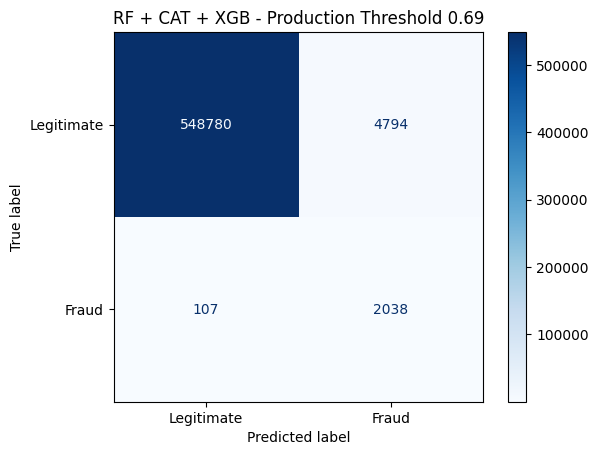

TN: 548780
FP: 4794
FN: 107
TP: 2038
time: 91.1 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
plot_confusion_matrix_for_threshold(
    y_true=y_true,
    y_prob=y_prob,
    threshold=production_threshold,
    title=f"{production_stack_name} - Production Threshold {production_threshold}"
)


# Random Transaction Inference Demo


In [ ]:
def run_random_transaction_demo(data_df, threshold=None):
    if threshold is None:
        threshold = production_threshold

    random_index = np.random.choice(data_df.index)
    transaction_df = data_df.loc[[random_index]].copy()

    prediction_df = predict_fraud_selected_stack(
        transaction_df,
        threshold=threshold
    )

    transaction_info_cols = [
        "trans_date_trans_time",
        "merchant",
        "category",
        "amt",
        "gender",
        "city",
        "state",
        "job",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
    ]

    available_info_cols = [
        col for col in transaction_info_cols
        if col in transaction_df.columns
    ]

    print("=" * 90)
    print("RANDOM TRANSACTION SELECTED")
    print("=" * 90)

    print("Dataset index:", random_index)

    if "is_fraud" in transaction_df.columns:
        true_label_num = int(transaction_df["is_fraud"].iloc[0])
        true_label_text = "Fraud" if true_label_num == 1 else "Legitimate"

        print("True Label:", true_label_text)
        print("True Label Value:", true_label_num)

    print("\nTransaction Details:")
    display(transaction_df[available_info_cols].T.rename(columns={random_index: "Value"}))

    print("\nModel Prediction Details:")
    display(prediction_df.T.rename(columns={0: "Value"}))

    stacking_prob = float(prediction_df["stacking_prob"].iloc[0])
    final_prediction = int(prediction_df["final_prediction"].iloc[0])
    final_label = prediction_df["final_label"].iloc[0]
    threshold_used = float(prediction_df["threshold_used"].iloc[0])

    print("=" * 90)
    print("FINAL DECISION")
    print("=" * 90)

    print("Stacking Fraud Probability:", round(stacking_prob, 8))
    print("Fraud Probability Percent:", round(stacking_prob * 100, 4), "%")
    print("Threshold Used:", threshold_used)
    print("Final Prediction:", final_prediction)
    print("Final Label:", final_label)

    if "is_fraud" in transaction_df.columns:
        is_correct = final_prediction == true_label_num

        print("\nPrediction Correct:", is_correct)

        if is_correct:
            print("Result: Correct classification")
        else:
            print("Result: Wrong classification")

    return transaction_df, prediction_df


time: 790 µs (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
random_transaction, random_prediction = run_random_transaction_demo(
    test_df,
    threshold=production_threshold
)


RANDOM TRANSACTION SELECTED
Dataset index: 121958
True Label: Legitimate
True Label Value: 0

Transaction Details:


,Value
trans_date_trans_time,2020-08-03 02:22:25
merchant,fraud_McDermott-Rice
category,misc_pos
amt,66.76
gender,M
city,San Diego
state,CA
job,Chartered public finance accountant
lat,33.0067
long,-117.069



Model Prediction Details:


,Value
rf_prob,0.0
cat_prob,0.000018
xgb_prob,0.000102
stacking_prob,0.014535
fraud_probability_percent,1.4535
threshold_used,0.69
final_prediction,0
final_label,Legitimate


FINAL DECISION
Stacking Fraud Probability: 0.01453481
Fraud Probability Percent: 1.4535 %
Threshold Used: 0.69
Final Prediction: 0
Final Label: Legitimate

Prediction Correct: True
Result: Correct classification
time: 47.7 ms (started: 2026-06-18 08:18:15 +00:00)


# Prediction Case Study Explorer


In [ ]:
def build_case_study_dataset(raw_df, predictions_df):
    case_df = pd.concat(
        [
            raw_df.reset_index(drop=True),
            predictions_df.reset_index(drop=True)
        ],
        axis=1
    )

    if "is_fraud" not in case_df.columns:
        raise ValueError("The raw dataframe must contain 'is_fraud' for case study analysis.")

    case_df["true_label"] = case_df["is_fraud"].astype(int)
    case_df["predicted_label"] = case_df["final_prediction"].astype(int)

    case_df["prediction_case"] = np.select(
        [
            (case_df["true_label"] == 0) & (case_df["predicted_label"] == 0),
            (case_df["true_label"] == 1) & (case_df["predicted_label"] == 1),
            (case_df["true_label"] == 0) & (case_df["predicted_label"] == 1),
            (case_df["true_label"] == 1) & (case_df["predicted_label"] == 0),
        ],
        [
            "True Negative",
            "True Positive",
            "False Positive",
            "False Negative",
        ],
        default="Unknown"
    )

    return case_df


time: 420 µs (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
def display_prediction_case(case_df, case_name):
    selected_cases = case_df[
        case_df["prediction_case"] == case_name
    ]

    if len(selected_cases) == 0:
        print(f"No cases found for: {case_name}")
        return None

    selected_row = selected_cases.sample(
        n=1,
        random_state=RANDOM_STATE
    ).iloc[0]

    selected_index = selected_row.name

    prediction_columns = [
        "rf_prob",
        "cat_prob",
        "xgb_prob",
        "stacking_prob",
        "fraud_probability_percent",
        "threshold_used",
        "final_prediction",
        "final_label",
    ]

    transaction_columns = [
        "trans_date_trans_time",
        "merchant",
        "category",
        "amt",
        "gender",
        "city",
        "state",
        "job",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "is_fraud",
    ]

    available_transaction_columns = [
        col for col in transaction_columns
        if col in case_df.columns
    ]

    print("=" * 90)
    print(case_name.upper())
    print("=" * 90)

    print("Dataset index:", selected_index)
    print("True Label:", "Fraud" if int(selected_row["true_label"]) == 1 else "Legitimate")
    print("Predicted Label:", selected_row["final_label"])

    print("\nTransaction Details:")
    display(
        selected_row[available_transaction_columns]
        .to_frame(name="Value")
    )

    print("\nModel Prediction Details:")
    display(
        selected_row[prediction_columns]
        .to_frame(name="Value")
    )

    print("\nBusiness Interpretation:")

    if case_name == "True Negative":
        print("The transaction was legitimate and the model correctly approved it.")

    elif case_name == "True Positive":
        print("The transaction was fraud and the model correctly flagged it for verification.")

    elif case_name == "False Positive":
        print("The transaction was legitimate but the model flagged it as suspicious.")
        print("This is why the system should use customer verification instead of automatic rejection.")

    elif case_name == "False Negative":
        print("The transaction was fraud but the model approved it.")
        print("These cases are important for future error analysis and model improvement.")

    return selected_row


time: 692 µs (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
case_study_df = build_case_study_dataset(
    test_df,
    test_predictions
)


time: 81.3 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
case_study_df["prediction_case"].value_counts()


,count
prediction_case,
True Negative,548780
False Positive,4794
True Positive,2038
False Negative,107


time: 17.7 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
display_prediction_case(case_study_df, "True Positive")


TRUE POSITIVE
Dataset index: 301866
True Label: Fraud
Predicted Label: Fraud

Transaction Details:


,Value
trans_date_trans_time,2020-10-13 02:57:06
merchant,fraud_Bednar Group
category,misc_net
amt,898.83
gender,F
city,Halstad
state,MN
job,"Scientist, audiological"
lat,47.3551
long,-96.798



Model Prediction Details:


,Value
rf_prob,0.462335
cat_prob,0.981158
xgb_prob,0.959285
stacking_prob,0.999007
fraud_probability_percent,99.9007
threshold_used,0.69
final_prediction,1
final_label,Fraud



Business Interpretation:
The transaction was fraud and the model correctly flagged it for verification.


,301866
Unnamed: 0,301866
trans_date_trans_time,2020-10-13 02:57:06
cc_num,4129767952109660
merchant,fraud_Bednar Group
category,misc_net
amt,898.83
first,Cheryl
last,Ballard
gender,F
street,248 James Squares Apt. 838


time: 22.5 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
display_prediction_case(case_study_df, "False Positive")


FALSE POSITIVE
Dataset index: 62097
True Label: Legitimate
Predicted Label: Fraud

Transaction Details:


,Value
trans_date_trans_time,2020-07-12 23:31:25
merchant,fraud_Wilkinson LLC
category,personal_care
amt,23.15
gender,F
city,Independence
state,MO
job,"Engineer, production"
lat,39.1412
long,-94.3515



Model Prediction Details:


,Value
rf_prob,0.035785
cat_prob,0.815756
xgb_prob,0.872611
stacking_prob,0.992015
fraud_probability_percent,99.2015
threshold_used,0.69
final_prediction,1
final_label,Fraud



Business Interpretation:
The transaction was legitimate but the model flagged it as suspicious.
This is why the system should use customer verification instead of automatic rejection.


,62097
Unnamed: 0,62097
trans_date_trans_time,2020-07-12 23:31:25
cc_num,30135235368675
merchant,fraud_Wilkinson LLC
category,personal_care
amt,23.15
first,Amanda
last,Williams
gender,F
street,02018 Gary Key Apt. 911


time: 22.1 ms (started: 2026-06-18 08:18:15 +00:00)


In [ ]:
display_prediction_case(case_study_df, "False Negative")


FALSE NEGATIVE
Dataset index: 329800
True Label: Fraud
Predicted Label: Legitimate

Transaction Details:


,Value
trans_date_trans_time,2020-10-25 20:43:20
merchant,fraud_Bednar Group
category,misc_net
amt,614.29
gender,F
city,Wever
state,IA
job,Quantity surveyor
lat,40.7067
long,-91.2268



Model Prediction Details:


,Value
rf_prob,0.023928
cat_prob,0.258537
xgb_prob,0.082752
stacking_prob,0.088958
fraud_probability_percent,8.8958
threshold_used,0.69
final_prediction,0
final_label,Legitimate



Business Interpretation:
The transaction was fraud but the model approved it.
These cases are important for future error analysis and model improvement.


,329800
Unnamed: 0,329800
trans_date_trans_time,2020-10-25 20:43:20
cc_num,4295296907373
merchant,fraud_Bednar Group
category,misc_net
amt,614.29
first,Destiny
last,Fowler
gender,F
street,007 Tonya Isle Suite 299


time: 19.5 ms (started: 2026-06-18 08:18:15 +00:00)


# Notebook Summary

This notebook performs production inference using the selected fraud detection stack identified during the meta-feature combination study.

The pipeline loads the saved production artifacts, recreates the training feature engineering process, applies the saved preprocessing pipeline, generates probabilities from the selected base models, and constructs the required meta-features for the Logistic Regression meta-model.

The final fraud probability is converted into a decision using the production threshold selected during the business optimization study.

The notebook also evaluates performance on the Kaggle test dataset, performs threshold analysis, generates fraud alerts, and provides transaction-level prediction examples for model interpretation.

No model training is performed in this notebook.